# Projeto 1 — EDA | Retail Sales, Promotions & Demand

## Objetivo
Realizar a exploração inicial da base antes de qualquer transformação definitiva, identificando:

- estrutura e qualidade dos dados;
- inconsistências que precisam de correção;
- comportamento comercial das lojas;
- categorias com maior volume de vendas;
- relação inicial entre preço, promoção, desconto e unidades vendidas.

> **Regra do projeto:** os dados originais são preservados durante o EDA.  
> As correções e features são aplicadas somente ao final, quando será gerada a base tratada para as próximas fases.


## 1. Importação das bibliotecas e leitura da base


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO_ORIGINAL = "retail_store_sales_promotions_demand.csv"

df = pd.read_csv(ARQUIVO_ORIGINAL)

# Trabalhamos com uma cópia para preservar o dataframe de origem.
eda = df.copy()

eda.head()


,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday


## 2. Visão geral da base
Antes de corrigir ou criar variáveis, verificamos tamanho, tipos, período disponível, valores ausentes e duplicidades.


In [2]:
print(f"Linhas: {eda.shape[0]:,}")
print(f"Colunas: {eda.shape[1]}")
print("\nColunas:")
print(eda.columns.tolist())

print("\nTipos de dados:")
display(eda.dtypes.to_frame("dtype"))

print("\nValores ausentes:")
display(eda.isna().sum().to_frame("missing"))

print(f"\nLinhas duplicadas: {eda.duplicated().sum():,}")


Linhas: 2,800
Colunas: 10

Colunas:
['store_id', 'product_id', 'date', 'category', 'price', 'promotion_active', 'discount_percent', 'units_sold', 'inventory_level', 'day_of_week']

Tipos de dados:


,dtype
store_id,int64
product_id,int64
date,str
category,str
price,int64
promotion_active,str
discount_percent,int64
units_sold,int64
inventory_level,int64
day_of_week,str



Valores ausentes:


,missing
store_id,0
product_id,0
date,0
category,0
price,0
promotion_active,0
discount_percent,0
units_sold,0
inventory_level,0
day_of_week,0



Linhas duplicadas: 0


In [3]:
# A data ainda veio como texto no CSV.
# A conversão abaixo é feita apenas na cópia de trabalho do EDA.
eda["date"] = pd.to_datetime(eda["date"])

print(f"Período da base: {eda['date'].min().date()} a {eda['date'].max().date()}")
print(f"Número de lojas: {eda['store_id'].nunique()}")
print(f"Número de produtos distintos: {eda['product_id'].nunique()}")
print(f"Número de categorias: {eda['category'].nunique()}")


Período da base: 2024-01-01 a 2024-12-31
Número de lojas: 50
Número de produtos distintos: 947
Número de categorias: 5


### Interpretação dos identificadores

- `store_id`: identifica uma loja específica da rede. Portanto, pode ser usado para comparar o desempenho comercial entre unidades e descobrir quais categorias cada loja vende mais.
- `product_id`: identifica o produto. Ele **não é único por linha**, pois o mesmo produto pode aparecer em mais de uma observação, loja ou data.
- `date`: representa a data da observação e será a referência oficial para criação de atributos de calendário.


In [4]:
# Verificando se product_id é único por linha
total_linhas = len(eda)
produtos_distintos = eda["product_id"].nunique()
repeticoes_product_id = eda["product_id"].duplicated().sum()

print(f"Total de linhas: {total_linhas:,}")
print(f"Product IDs distintos: {produtos_distintos:,}")
print(f"Ocorrências repetidas de product_id: {repeticoes_product_id:,}")

# Quantas vezes cada produto aparece?
display(
    eda.groupby("product_id")
       .size()
       .describe()
       .to_frame("observacoes_por_produto")
)


Total de linhas: 2,800
Product IDs distintos: 947
Ocorrências repetidas de product_id: 1,853


,observacoes_por_produto
count,947.00
mean,2.96
std,1.55
min,1.00
25%,2.00
50%,3.00
75%,4.00
max,9.00


## 3. Validação da coluna `day_of_week`

A base possui uma coluna pronta chamada `day_of_week`, mas uma variável derivada de data deve ser validada contra a própria data antes de ser utilizada.

Para isso, calculamos o dia correto diretamente de `date` com:

```python
eda["date"].dt.day_name()
```

Neste momento **não substituímos** o valor original. Primeiro medimos a discrepância.


In [5]:
eda["calculated_day_of_week"] = eda["date"].dt.day_name()

eda["day_of_week_match"] = (
    eda["day_of_week"] == eda["calculated_day_of_week"]
)

total = len(eda)
corretos = eda["day_of_week_match"].sum()
incorretos = (~eda["day_of_week_match"]).sum()

print(f"Registros analisados: {total:,}")
print(f"Dia da semana correto: {corretos:,} ({corretos/total:.2%})")
print(f"Dia da semana divergente: {incorretos:,} ({incorretos/total:.2%})")


Registros analisados: 2,800
Dia da semana correto: 397 (14.18%)
Dia da semana divergente: 2,403 (85.82%)


### Exemplos de divergência

A função abaixo filtra apenas as linhas em que o valor recebido na base não corresponde ao dia calculado a partir da data.


In [6]:
divergencias_dia = eda.loc[
    ~eda["day_of_week_match"],
    ["date", "day_of_week", "calculated_day_of_week"]
]

display(divergencias_dia.head(15))


,date,day_of_week,calculated_day_of_week
0,2024-09-19,Friday,Thursday
1,2024-12-21,Wednesday,Saturday
2,2024-09-27,Saturday,Friday
3,2024-06-16,Tuesday,Sunday
4,2024-12-05,Saturday,Thursday
5,2024-06-10,Friday,Monday
6,2024-05-28,Monday,Tuesday
7,2024-07-11,Tuesday,Thursday
8,2024-06-08,Tuesday,Saturday
9,2024-02-21,Monday,Wednesday


### Matriz de conferência

Uma tabela cruzada permite enxergar rapidamente como os valores informados em `day_of_week` estão distribuídos em relação ao dia efetivamente calculado.


In [7]:
weekday_check = pd.crosstab(
    eda["day_of_week"],
    eda["calculated_day_of_week"],
    rownames=["Informado na base"],
    colnames=["Calculado pela data"]
)

display(weekday_check)


Calculado pela data,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Informado na base,,,,,,,
Friday,55,70,50,51,69,57,53
Monday,78,53,55,56,63,51,50
Saturday,59,58,61,45,52,66,45
Sunday,53,60,59,57,56,67,57
Thursday,63,56,58,54,62,61,51
Tuesday,60,52,67,51,62,56,60
Wednesday,64,54,53,52,52,53,53


In [8]:
weekday_accuracy = (
    eda.groupby("day_of_week")["day_of_week_match"]
       .agg(["count", "sum", "mean"])
       .rename(columns={
           "count": "registros",
           "sum": "corretos",
           "mean": "taxa_acerto"
       })
)

weekday_accuracy["taxa_acerto"] = weekday_accuracy["taxa_acerto"].map(lambda x: f"{x:.2%}")
display(weekday_accuracy)


,registros,corretos,taxa_acerto
day_of_week,,,
Friday,405,55,13.58%
Monday,406,53,13.05%
Saturday,386,61,15.80%
Sunday,409,57,13.94%
Thursday,405,62,15.31%
Tuesday,408,56,13.73%
Wednesday,381,53,13.91%


### Decisão de tratamento

A coluna original apresenta divergência relevante em relação à data.

Por isso, na etapa final de tratamento:

1. o valor original será preservado em `day_of_week_original`;
2. `day_of_week` será recalculado diretamente de `date`;
3. será criada uma flag `weekday_was_correct` para registrar se o valor original estava correto.

Essa abordagem preserva **rastreabilidade e auditabilidade** do tratamento.


## 4. Análise comercial por loja

Como `store_id` representa uma unidade específica da rede, podemos avaliar o mix de vendas de cada loja.

A métrica principal nesta primeira leitura será `units_sold`.


In [9]:
store_summary = (
    eda.groupby("store_id")
       .agg(
           registros=("product_id", "size"),
           produtos_distintos=("product_id", "nunique"),
           unidades_vendidas=("units_sold", "sum"),
           estoque_medio=("inventory_level", "mean"),
           preco_medio=("price", "mean")
       )
       .sort_values("unidades_vendidas", ascending=False)
)

display(store_summary.head(10))


,registros,produtos_distintos,unidades_vendidas,estoque_medio,preco_medio
store_id,,,,,
16,70,67,1892,279.66,"1,570.90"
29,75,71,1892,260.29,"1,393.21"
18,67,64,1883,285.16,"1,326.19"
27,68,67,1816,259.62,"1,459.71"
15,61,59,1808,249.44,"1,479.15"
24,63,62,1797,244.27,"1,661.57"
20,65,64,1745,258.62,"1,632.63"
37,65,62,1677,257.60,"1,498.95"
46,58,56,1659,244.60,"1,429.72"


### Categoria mais vendida em cada loja

Primeiro agregamos `units_sold` por `store_id + category`.  
Em seguida, selecionamos a categoria com maior quantidade vendida dentro de cada loja.


In [10]:
store_category_sales = (
    eda.groupby(["store_id", "category"], as_index=False)
       .agg(
           unidades_vendidas=("units_sold", "sum"),
           registros=("product_id", "size"),
           produtos_distintos=("product_id", "nunique")
       )
)

top_category_by_store = (
    store_category_sales
      .sort_values(["store_id", "unidades_vendidas"], ascending=[True, False])
      .groupby("store_id", as_index=False)
      .first()
      .rename(columns={"category": "categoria_mais_vendida"})
)

display(top_category_by_store.head(15))


,store_id,categoria_mais_vendida,unidades_vendidas,registros,produtos_distintos
0,1,Clothing,338,12,11
1,2,Electronics,317,11,11
2,3,Personal Care,282,11,11
3,4,Home,447,16,16
4,5,Home,464,16,16
5,6,Grocery,420,18,18
6,7,Grocery,464,17,17
7,8,Electronics,326,14,14
8,9,Home,403,15,15
9,10,Grocery,415,13,13


### Matriz loja × categoria

Esta tabela é especialmente útil para identificar o perfil comercial de cada unidade.


In [11]:
store_category_matrix = pd.pivot_table(
    eda,
    index="store_id",
    columns="category",
    values="units_sold",
    aggfunc="sum",
    fill_value=0
)

display(store_category_matrix.head(15))


category,Clothing,Electronics,Grocery,Home,Personal Care
store_id,,,,,
1,338,241,325,315,189
2,251,317,181,227,294
3,272,262,267,197,282
4,251,280,231,447,234
5,203,384,176,464,152
6,310,153,420,383,299
7,153,172,464,226,316
8,308,326,318,280,273
9,252,218,235,403,255


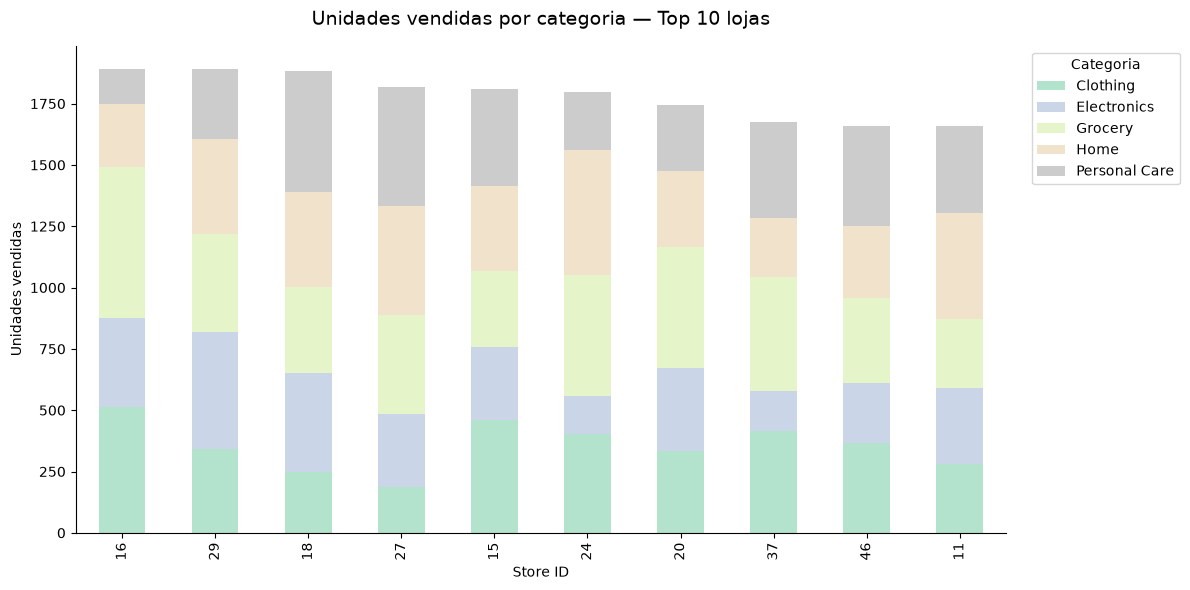

In [22]:
# Exemplo visual: composição das vendas das 10 lojas com maior volume total
# Exemplo visual: composição das vendas das 10 lojas com maior volume total
top_10_stores = (
    eda.groupby("store_id")["units_sold"]
       .sum()
       .nlargest(10)
       .index
)

plot_data = store_category_matrix.loc[top_10_stores]

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Pastel2"
)

plt.title(
    "Unidades vendidas por categoria — Top 10 lojas",
    fontsize=14,
    pad=15
)

plt.xlabel("Store ID")
plt.ylabel("Unidades vendidas")

plt.legend(
    title="Categoria",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Visual mais limpo
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Análise geral por categoria


In [13]:
category_summary = (
    eda.groupby("category")
       .agg(
           registros=("product_id", "size"),
           produtos_distintos=("product_id", "nunique"),
           unidades_vendidas=("units_sold", "sum"),
           preco_medio=("price", "mean"),
           desconto_medio=("discount_percent", "mean"),
           estoque_medio=("inventory_level", "mean")
       )
       .sort_values("unidades_vendidas", ascending=False)
)

display(category_summary)


,registros,produtos_distintos,unidades_vendidas,preco_medio,desconto_medio,estoque_medio
category,,,,,,
Grocery,578,447,15288,"1,556.10",6.90,253.76
Home,569,442,15069,"1,449.31",6.51,256.67
Personal Care,561,440,14787,"1,527.18",6.90,252.44
Clothing,556,429,14669,"1,579.41",7.20,253.43
Electronics,536,422,13799,"1,479.33",6.71,256.63


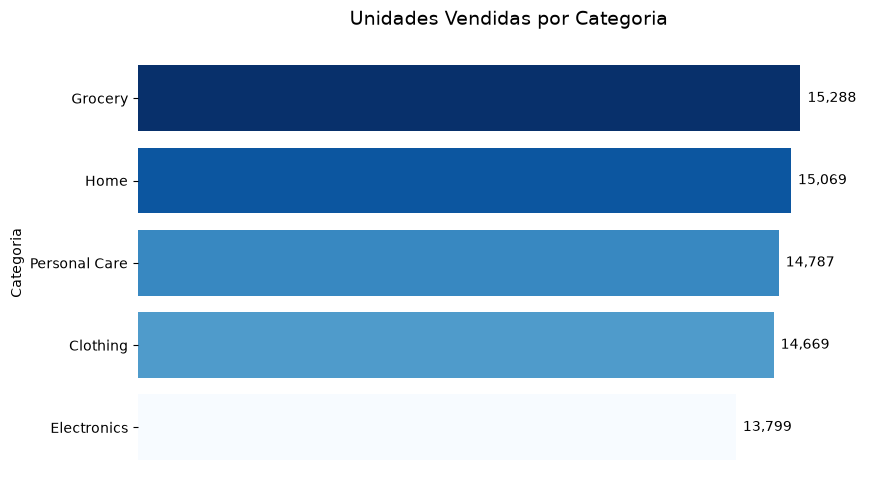

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Ordenar as categorias pelo volume de vendas
dados_plot = (
    category_summary["unidades_vendidas"]
    .sort_values()
)

# Normaliza os valores para aplicar o gradiente
norm = mcolors.Normalize(
    vmin=dados_plot.min(),
    vmax=dados_plot.max()
)

# Gradiente de cores
cmap = plt.cm.Blues
cores = cmap(norm(dados_plot.values))

# Criação do gráfico
fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.barh(
    dados_plot.index,
    dados_plot.values,
    color=cores
)

# Rótulos diretamente nas barras
ax.bar_label(
    barras,
    labels=[f"{valor:,.0f}" for valor in dados_plot.values],
    padding=5,
    fontsize=10
)

# Título e eixo categórico
ax.set_title(
    "Unidades Vendidas por Categoria",
    fontsize=14,
    pad=15
)

ax.set_ylabel("Categoria")
ax.set_xlabel("")

# Remove eixo X e linhas desnecessárias
ax.xaxis.set_visible(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Espaço adicional para os rótulos
ax.set_xlim(0, dados_plot.max() * 1.12)

plt.tight_layout()
plt.show()

## 6. Preço, desconto e promoção

Neste estágio fazemos apenas uma leitura exploratória.  
A presença de associação entre desconto/promoção e vendas **não deve ser interpretada automaticamente como causalidade**.


In [15]:
promotion_summary = (
    eda.groupby("promotion_active")
       .agg(
           registros=("units_sold", "size"),
           unidades_medias=("units_sold", "mean"),
           preco_medio=("price", "mean"),
           desconto_medio=("discount_percent", "mean")
       )
)

display(promotion_summary)


,registros,unidades_medias,preco_medio,desconto_medio
promotion_active,,,,
No,1370,24.92,"1,503.43",0.00
Yes,1430,27.60,"1,533.01",13.40


In [16]:
discount_summary = (
    eda.groupby("discount_percent")
       .agg(
           registros=("units_sold", "size"),
           unidades_medias=("units_sold", "mean"),
           preco_medio=("price", "mean")
       )
)

display(discount_summary)


,registros,unidades_medias,preco_medio
discount_percent,,,
0,1592,24.98,"1,509.28"
5,240,25.84,"1,554.04"
10,252,26.17,"1,518.07"
15,235,28.06,"1,611.31"
20,251,28.59,"1,489.75"
30,230,31.67,"1,482.73"


## 7. Comportamento temporal antes do tratamento

A análise abaixo usa somente a coluna `date`, que é a fonte confiável para calendário.  
Não utilizamos o `day_of_week` original nas análises temporais.


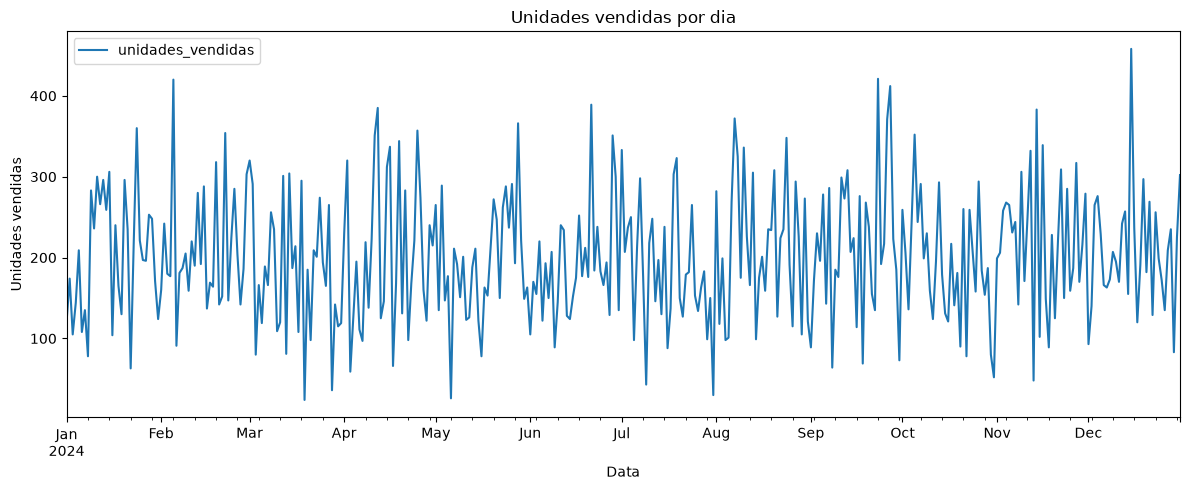

In [17]:
daily_sales = (
    eda.groupby("date", as_index=False)
       .agg(
           unidades_vendidas=("units_sold", "sum"),
           estoque_total=("inventory_level", "sum")
       )
       .sort_values("date")
)

daily_sales.plot(
    x="date",
    y="unidades_vendidas",
    figsize=(12, 5)
)

plt.title("Unidades vendidas por dia")
plt.xlabel("Data")
plt.ylabel("Unidades vendidas")
plt.tight_layout()
plt.show()


# 8. Tratamento final e geração da base analítica

Somente após concluir o EDA aplicamos as transformações definitivas.

Tratamentos:

- conversão definitiva de `date` para `datetime`;
- preservação do `day_of_week` original;
- correção de `day_of_week` a partir da data;
- flag de qualidade do dia da semana;
- criação de atributos de calendário;
- criação de métricas financeiras derivadas;
- exportação da base tratada.

### Premissa financeira

Consideramos `price` como preço-base antes do desconto:

\[
Preço\ efetivo = Preço \times (1 - Desconto)
\]

\[
Receita\ líquida\ estimada = Preço\ efetivo \times Unidades\ vendidas
\]

Como a base não fornece explicitamente a receita líquida transacionada, usamos o sufixo `_est` para deixar claro que se trata de uma métrica derivada sob premissa.


In [18]:
# Recomeçamos a partir da base original para garantir
# que o tratamento final seja reproduzível e independente do EDA.
tratada = df.copy()

# 1. Tipagem
tratada["date"] = pd.to_datetime(tratada["date"])

# 2. Correção auditável do dia da semana
tratada["day_of_week_original"] = tratada["day_of_week"]
tratada["day_of_week"] = tratada["date"].dt.day_name()
tratada["weekday_was_correct"] = (
    tratada["day_of_week_original"] == tratada["day_of_week"]
)

# 3. Features temporais
tratada["year"] = tratada["date"].dt.year
tratada["month"] = tratada["date"].dt.month
tratada["month_name"] = tratada["date"].dt.month_name()
tratada["quarter"] = tratada["date"].dt.quarter
tratada["week"] = tratada["date"].dt.isocalendar().week.astype(int)
tratada["is_weekend"] = tratada["date"].dt.dayofweek >= 5

# 4. Features financeiras
tratada["gross_revenue"] = (
    tratada["price"] * tratada["units_sold"]
)

tratada["effective_price_est"] = (
    tratada["price"] *
    (1 - tratada["discount_percent"] / 100)
)

tratada["net_sales_est"] = (
    tratada["effective_price_est"] *
    tratada["units_sold"]
)

tratada.head()


,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,day_of_week_original,weekday_was_correct,year,month,month_name,quarter,week,is_weekend,gross_revenue,effective_price_est,net_sales_est
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Thursday,Friday,False,2024,9,September,3,38,False,32334,"1,902.00","32,334.00"
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Saturday,Wednesday,False,2024,12,December,4,51,True,36806,"2,629.00","36,806.00"
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Friday,Saturday,False,2024,9,September,3,39,False,62200,"2,488.00","62,200.00"
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Sunday,Tuesday,False,2024,6,June,2,24,True,2051,278.35,"1,948.45"
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Thursday,Saturday,False,2024,12,December,4,49,False,91390,"1,976.00","73,112.00"


## 9. Validação pós-tratamento


In [19]:
print("Dimensão da base tratada:", tratada.shape)
print("\nValores ausentes:")
display(tratada.isna().sum().to_frame("missing"))

print(f"\nDuplicidades: {tratada.duplicated().sum():,}")

print(
    "\nTaxa de registros cujo day_of_week original estava correto:",
    f"{tratada['weekday_was_correct'].mean():.2%}"
)

# Conferência final: após a correção, todos os dias devem bater com a data.
validacao_final = (
    tratada["day_of_week"] == tratada["date"].dt.day_name()
).all()

print("Day of week corrigido em conformidade com date:", validacao_final)


Dimensão da base tratada: (2800, 21)

Valores ausentes:


,missing
store_id,0
product_id,0
date,0
category,0
price,0
promotion_active,0
discount_percent,0
units_sold,0
inventory_level,0
day_of_week,0



Duplicidades: 0

Taxa de registros cujo day_of_week original estava correto: 14.18%
Day of week corrigido em conformidade com date: True


## 10. Exportação para as próximas fases

A base abaixo será a fonte das etapas de:

1. Forecast;
2. Financial Planning e cenários;
3. Inventory & Profit Optimization;
4. Pricing & Margin Optimization.


In [20]:
ARQUIVO_TRATADO = "retail_sales_cleaned_project1.csv"

tratada.to_csv(
    ARQUIVO_TRATADO,
    index=False,
    encoding="utf-8-sig"
)

print(f"Base tratada gerada com sucesso: {ARQUIVO_TRATADO}")
print(f"Linhas: {len(tratada):,}")
print(f"Colunas: {tratada.shape[1]}")


Base tratada gerada com sucesso: retail_sales_cleaned_project1.csv
Linhas: 2,800
Colunas: 21
